# Assignment 2 -- ML4F 2023

## Instructions
* This assignment covers the material discussed in Lectures ML1 - ML9. 
* Each group submits _only one_ notebook via canvas on the assignment page. 
* The notebook should be named `assignment1_groupXX.ipynb` where `XX` is your group number,  
e.g. for group 3 this will be `assignment1_group03.ipynb`.
* The notebook should run without raising any errors. 
* We recommend keeping the folder structure
```
assignment/
    data/
    lib/
    assignment1_groupXX.ipynb
```
* We strongly recommend git, as you are encouraged to collaborate and split up the work and maybe even start independently. To see how to set up your own repo for your group, see `VU Workshop Introduction to Version Control with GIT.pptx` discussed in week 2.
* Do not spend time on optimizing the speed of your code. However, if it runs for more than 5 minutes, we will terminate it.
* We strongly encourage you to experiment, try different approaches and combinations and get to know the problem from alternative angles. But the final notebook should only contain the necessary results for grading.
----

<div style="font-size:24px; text-align:center; font-weight:bold">Good luck!</div>

----

# Assignment 2 - Neural Nets & Explainability

The hedge fund managers of G. Mane Investments are looking into trading in Call options on small cap stocks. You are assigned a stock on Canvas, and the option data on this stock is achieved using the function given below. Do not alter anything about the function, as it creates a nice dataset containing the following features:

* Forward Price
* Strike
* Implied Volatility
* Maturity
* Volume
* Open Interest
* Bid
* Ask
* Price

Make sure to download the dataset as CSV right away, so it doesn't change throughout the week, when the markets trade.

Since there is only a limited amount of option data available, the fund managers would like you to use comparable stocks to train a ML model on, so they can use it to price their options accurately. 

State your imports below.

In [2]:
pip install yfinance


                                              0.0/69.0 kB ? eta -:--:--
     ---------------------------------------- 69.0/69.0 kB 3.9 MB/s eta 0:00:00
                                              0.0/62.6 kB ? eta -:--:--
     ---------------------------------------- 62.6/62.6 kB 3.5 MB/s eta 0:00:00
                                              0.0/2.9 MB ? eta -:--:--
     -----                                    0.4/2.9 MB 8.9 MB/s eta 0:00:01
     ----------                               0.8/2.9 MB 10.2 MB/s eta 0:00:01
     -----------------                        1.3/2.9 MB 10.2 MB/s eta 0:00:01
     -----------------------                  1.7/2.9 MB 10.0 MB/s eta 0:00:01
     -----------------------------            2.2/2.9 MB 9.8 MB/s eta 0:00:01
     ----------------------------------       2.5/2.9 MB 9.5 MB/s eta 0:00:01
     ---------------------------------------  2.9/2.9 MB 9.4 MB/s eta 0:00:01
     ---------------------------------------- 2.9/2.9 MB 9.0 MB/s eta 0:00:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.41 requires requests_mock, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
conda-repo-cli 1.0.41 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.41 requires nbformat==5.4.0, but you have nbformat 5.7.0 which is incompatible.
conda-repo-cli 1.0.41 requires requests==2.28.1, but you have requests 2.31.0 which is incompatible.


In [156]:
pip install shap


                                              0.0/447.3 kB ? eta -:--:--
     ---------------------------------     409.6/447.3 kB 12.5 MB/s eta 0:00:01
     -------------------------------------- 447.3/447.3 kB 9.3 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import datetime as datetime
import pandas as pd
import numpy as np

def getOptionData(s):
    """
    Purpose:
        Get stock/index option data into a usable format
        
    Input:
        s    string, asset ticker
       
    Output:
       df    Dataframe, option data
    """
    ticker = yf.Ticker(s)
    exps = ticker.options
    expirations = [datetime.datetime.strptime(i, '%Y-%m-%d') for i in exps]  
    s0 = ticker.history(period="1d")['Close'].iloc[0]
    vT = []
    vF = []
    c = 0
    for i in expirations:
        diff = i - datetime.datetime.now()
        if diff.total_seconds() > 0:
            ttm = diff.total_seconds() / 31536000
            vT.append(ttm) # Set TTM to yearly
            f0 = s0 * np.exp(ttm) # Get Forward Price
            vF.append(f0)
        else:
            c += 1
    vK = [] # ATM Strike
    vIV = [] # ATM IV
    vC = [] # ATM Call Price 
    vnF = []
    vnT = []
    vV = []
    vO = []
    vA = []
    vB = []
    for i in range(c, len(exps)):
        options = ticker.option_chain(exps[i])
        for index, row in options.calls.iterrows():
            vnF.append(vF[i - c])
            vK.append(row['strike'])
            vIV.append(row['impliedVolatility'])
            vC.append(row['lastPrice'])
            vnT.append(vT[i - c])
            vV.append(row['volume'])
            vO.append(row['openInterest'])
            vA.append(row['ask'])
            vB.append(row['bid'])
    df = pd.DataFrame([vnF, vK, vIV, vnT, vV, vO, vB, vA, vC]).transpose()
    df = df.set_axis(['Forward', 'Strike', 'Implied Volatility', 'Maturity', 'Volume', 'Open Interest', 'Bid', 'Ask', 'Call'], axis=1)
    return df

In [8]:
BZH = getOptionData('BZH')
TMHC = getOptionData('TMHC')
KBH = getOptionData('KBH')
MHO = getOptionData('MHO')
TPH = getOptionData('TPH')
MTH = getOptionData('MTH')

In [15]:
BZH['Ticker'] = 'BZH'
TMHC['Ticker'] = 'TMHC'
KBH['Ticker'] = 'KBH'
MHO['Ticker'] = 'MHO'
TPH['Ticker'] = 'TPH'
MTH['Ticker'] = 'MTH'

In [16]:
data = pd.concat([BZH, TMHC, KBH, MHO, TPH, MTH])

In [18]:
data.to_excel('OptionData.xlsx')

In [157]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import shap
from scipy.stats import mstats
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer

# Preprocessing (20 points)
*5 points for correct code*

*15 points for appropriate judgment of preprocessing measures*

---
The provided option data may contain some issues that need to be dealt with by preprocessing the data. Take a good look at the data and check for NaN's, outliers or other issues. 

Some options aren't being traded at all, because of a variety of reasons. See to it that these observations are dealt with appropriately.

In [38]:
data = pd.read_excel('OptionData.xlsx')

In [39]:
#fill na volume value with mean of volume
data = data.fillna(data['Volume'].mean())

(array([84., 77., 82., 17., 18.,  3., 37.,  0., 21., 38.,  0., 23.,  1.,
         0.,  0.,  8.,  0.,  0.,  0.,  0., 18.,  0.,  0.,  0.,  0.,  0.,
         0., 17.,  0.,  8.]),
 array([ 27.11626204,  41.13913643,  55.16201083,  69.18488523,
         83.20775963,  97.23063403, 111.25350842, 125.27638282,
        139.29925722, 153.32213162, 167.34500601, 181.36788041,
        195.39075481, 209.41362921, 223.43650361, 237.459378  ,
        251.4822524 , 265.5051268 , 279.5280012 , 293.55087559,
        307.57374999, 321.59662439, 335.61949879, 349.64237318,
        363.66524758, 377.68812198, 391.71099638, 405.73387078,
        419.75674517, 433.77961957, 447.80249397]),
 <BarContainer object of 30 artists>)

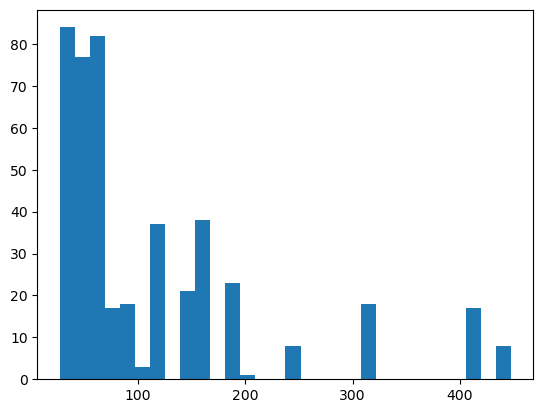

In [43]:
plt.hist(data['Forward'], bins = 30)

(array([ 4., 13., 37., 49., 50., 59., 50., 50., 14., 20.,  9.,  3., 12.,
         5., 14.,  5., 11.,  5.,  8.,  5.,  3.,  7.,  3.,  5.,  2.,  4.,
         2.,  1.,  1.,  1.]),
 array([  3.        ,  10.23333333,  17.46666667,  24.7       ,
         31.93333333,  39.16666667,  46.4       ,  53.63333333,
         60.86666667,  68.1       ,  75.33333333,  82.56666667,
         89.8       ,  97.03333333, 104.26666667, 111.5       ,
        118.73333333, 125.96666667, 133.2       , 140.43333333,
        147.66666667, 154.9       , 162.13333333, 169.36666667,
        176.6       , 183.83333333, 191.06666667, 198.3       ,
        205.53333333, 212.76666667, 220.        ]),
 <BarContainer object of 30 artists>)

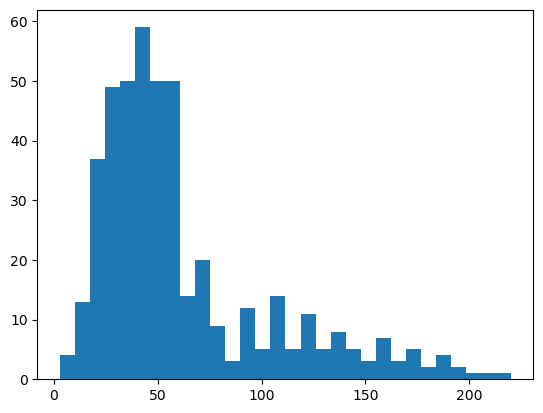

In [42]:
plt.hist(data['Strike'], bins = 30)

(array([ 39., 164., 167.,  41.,  13.,   6.,  10.,   1.,   1.,   1.,   1.,
          1.,   1.,   0.,   1.,   3.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   1.]),
 array([1.00000000e-05, 2.21233682e-01, 4.42457364e-01, 6.63681045e-01,
        8.84904727e-01, 1.10612841e+00, 1.32735209e+00, 1.54857577e+00,
        1.76979945e+00, 1.99102314e+00, 2.21224682e+00, 2.43347050e+00,
        2.65469418e+00, 2.87591786e+00, 3.09714155e+00, 3.31836523e+00,
        3.53958891e+00, 3.76081259e+00, 3.98203627e+00, 4.20325995e+00,
        4.42448364e+00, 4.64570732e+00, 4.86693100e+00, 5.08815468e+00,
        5.30937836e+00, 5.53060205e+00, 5.75182573e+00, 5.97304941e+00,
        6.19427309e+00, 6.41549677e+00, 6.63672045e+00]),
 <BarContainer object of 30 artists>)

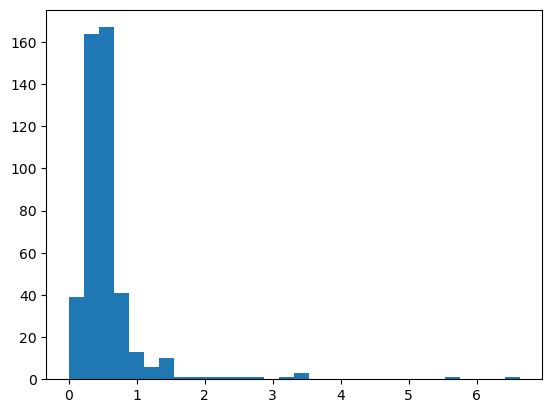

In [41]:
plt.hist(data['Implied Volatility'], bins = 30)

(array([138.,  98.,  28.,   0.,  23.,  43.,  22.,  26.,   4.,   0.,   0.,
          0.,   0.,   7.,  18.,  20.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,  17.,   8.]),
 array([0.00869337, 0.07965228, 0.15061118, 0.22157008, 0.29252899,
        0.36348789, 0.4344468 , 0.5054057 , 0.5763646 , 0.64732351,
        0.71828241, 0.78924132, 0.86020022, 0.93115912, 1.00211803,
        1.07307693, 1.14403584, 1.21499474, 1.28595365, 1.35691255,
        1.42787145, 1.49883036, 1.56978926, 1.64074817, 1.71170707,
        1.78266597, 1.85362488, 1.92458378, 1.99554269, 2.06650159,
        2.13746049]),
 <BarContainer object of 30 artists>)

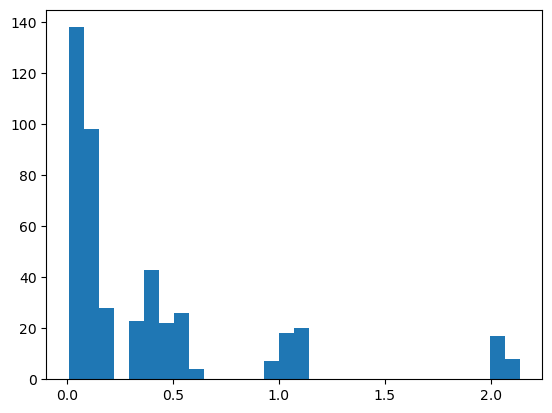

In [40]:
plt.hist(data['Maturity'], bins = 30)

(array([297., 109.,   7.,  13.,   3.,   6.,   3.,   2.,   1.,   1.,   1.,
          0.,   0.,   1.,   1.,   0.,   0.,   3.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   2.,   0.,   0.,   1.]),
 array([  1. ,   6.7,  12.4,  18.1,  23.8,  29.5,  35.2,  40.9,  46.6,
         52.3,  58. ,  63.7,  69.4,  75.1,  80.8,  86.5,  92.2,  97.9,
        103.6, 109.3, 115. , 120.7, 126.4, 132.1, 137.8, 143.5, 149.2,
        154.9, 160.6, 166.3, 172. ]),
 <BarContainer object of 30 artists>)

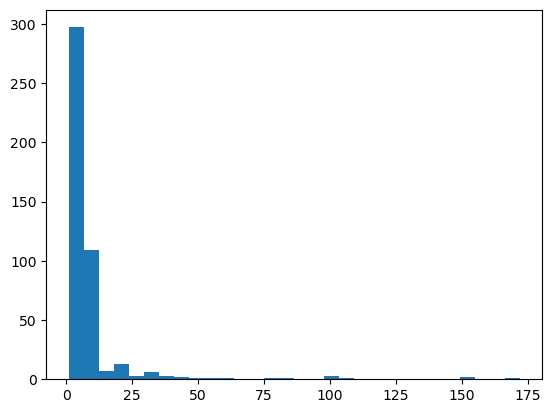

In [40]:
plt.hist(data['Volume'], bins = 30)

(array([375.,  36.,  10.,  11.,   3.,   7.,   3.,   0.,   1.,   0.,   2.,
          1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([   0.        ,  100.53333333,  201.06666667,  301.6       ,
         402.13333333,  502.66666667,  603.2       ,  703.73333333,
         804.26666667,  904.8       , 1005.33333333, 1105.86666667,
        1206.4       , 1306.93333333, 1407.46666667, 1508.        ,
        1608.53333333, 1709.06666667, 1809.6       , 1910.13333333,
        2010.66666667, 2111.2       , 2211.73333333, 2312.26666667,
        2412.8       , 2513.33333333, 2613.86666667, 2714.4       ,
        2814.93333333, 2915.46666667, 3016.        ]),
 <BarContainer object of 30 artists>)

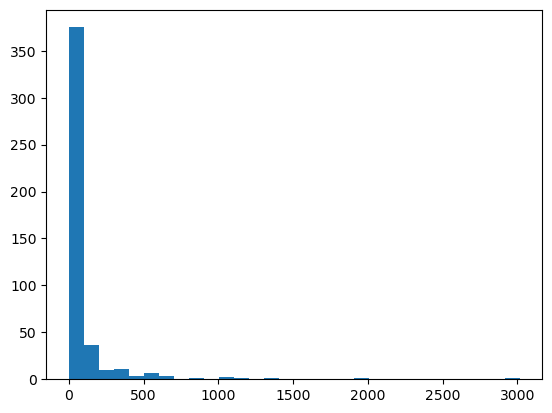

In [38]:
plt.hist(data['Open Interest'], bins = 30)

(array([171.,  43.,  35.,  33.,  39.,  19.,  20.,  16.,  15.,  11.,   9.,
          5.,   5.,   3.,   5.,   2.,   2.,   2.,   4.,   0.,   3.,   2.,
          3.,   1.,   0.,   0.,   1.,   0.,   0.,   3.]),
 array([ 0.  ,  2.22,  4.44,  6.66,  8.88, 11.1 , 13.32, 15.54, 17.76,
        19.98, 22.2 , 24.42, 26.64, 28.86, 31.08, 33.3 , 35.52, 37.74,
        39.96, 42.18, 44.4 , 46.62, 48.84, 51.06, 53.28, 55.5 , 57.72,
        59.94, 62.16, 64.38, 66.6 ]),
 <BarContainer object of 30 artists>)

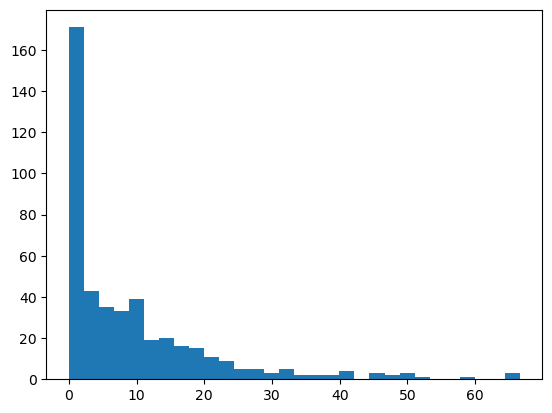

In [37]:
plt.hist(data['Bid'], bins = 30)

(array([155.,  44.,  46.,  35.,  37.,  22.,  18.,  17.,  18.,   7.,  11.,
          5.,   6.,   3.,   4.,   2.,   4.,   0.,   3.,   2.,   3.,   0.,
          5.,   1.,   0.,   0.,   1.,   0.,   1.,   2.]),
 array([ 0.        ,  2.38333333,  4.76666667,  7.15      ,  9.53333333,
        11.91666667, 14.3       , 16.68333333, 19.06666667, 21.45      ,
        23.83333333, 26.21666667, 28.6       , 30.98333333, 33.36666667,
        35.75      , 38.13333333, 40.51666667, 42.9       , 45.28333333,
        47.66666667, 50.05      , 52.43333333, 54.81666667, 57.2       ,
        59.58333333, 61.96666667, 64.35      , 66.73333333, 69.11666667,
        71.5       ]),
 <BarContainer object of 30 artists>)

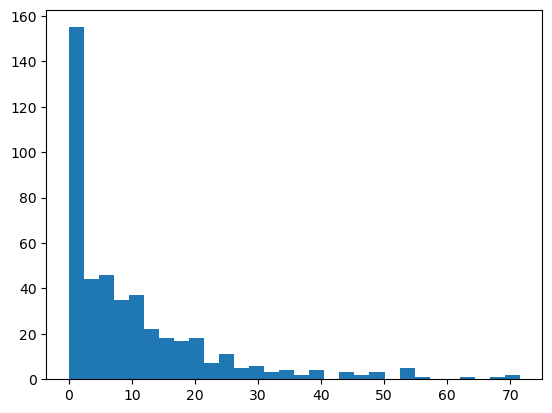

In [35]:
plt.hist(data['Ask'], bins = 30)

(array([153.,  54.,  51.,  41.,  26.,  27.,  18.,  13.,  10.,  11.,   6.,
          9.,   3.,   4.,   2.,   4.,   3.,   4.,   3.,   1.,   2.,   1.,
          1.,   0.,   0.,   2.,   0.,   1.,   0.,   2.]),
 array([3.00000000e-02, 2.23733333e+00, 4.44466667e+00, 6.65200000e+00,
        8.85933333e+00, 1.10666667e+01, 1.32740000e+01, 1.54813333e+01,
        1.76886667e+01, 1.98960000e+01, 2.21033333e+01, 2.43106667e+01,
        2.65180000e+01, 2.87253333e+01, 3.09326667e+01, 3.31400000e+01,
        3.53473333e+01, 3.75546667e+01, 3.97620000e+01, 4.19693333e+01,
        4.41766667e+01, 4.63840000e+01, 4.85913333e+01, 5.07986667e+01,
        5.30060000e+01, 5.52133333e+01, 5.74206667e+01, 5.96280000e+01,
        6.18353333e+01, 6.40426667e+01, 6.62500000e+01]),
 <BarContainer object of 30 artists>)

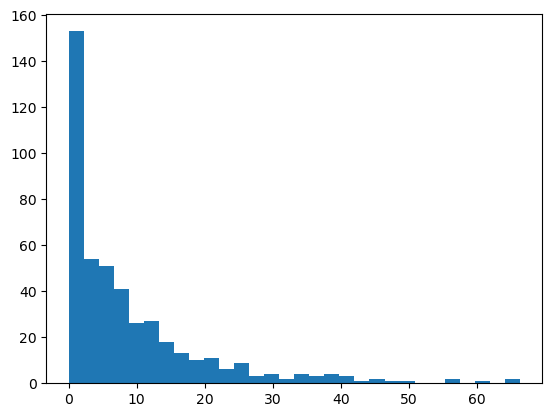

In [36]:
plt.hist(data['Call'], bins = 30)

In [56]:
#winsorize data 
forward_wins = mstats.winsorize(data['Forward'], limits=[0.05, 0.05])
#strike_wins = mstats.winsorize(data['Strike'], limits=[0.05, 0.05])
vola_wins = mstats.winsorize(data['Implied Volatility'], limits=[0.05, 0.05])
maturity_wins = mstats.winsorize(data['Maturity'], limits=[0.05, 0.05])
volume_wins = mstats.winsorize(data['Volume'], limits=[0.05, 0.05])
interest_wins = mstats.winsorize(data['Open Interest'], limits=[0.05, 0.05])
bid_wins = mstats.winsorize(data['Bid'], limits=[0.05, 0.05])
ask_wins = mstats.winsorize(data['Ask'], limits=[0.05, 0.05])
call_wins = mstats.winsorize(data['Call'], limits=[0.05, 0.05])

In [57]:
data_wins = pd.DataFrame([forward_wins, data['Strike'], vola_wins, maturity_wins, volume_wins, interest_wins, bid_wins, ask_wins, call_wins])
df_winsorized = data_wins.transpose()
df_winsorized['Ticker'] = data['Ticker']
df_winsorized.columns = data.columns
df_winsorized

,Forward,Strike,Implied Volatility,Maturity,Volume,Open Interest,Bid,Ask,Call,Ticker
0,27.116262,3.0,0.000010,0.047050,22.000000,22.0,10.6,11.6,9.80,BZH
1,27.116262,5.0,0.000010,0.047050,1.000000,3.0,17.0,17.8,16.50,BZH
2,27.116262,8.0,0.000010,0.047050,7.976804,1.0,5.6,6.1,6.38,BZH
3,27.116262,10.0,1.312503,0.047050,4.000000,6.0,15.6,16.5,17.33,BZH
4,27.116262,11.0,1.312503,0.047050,7.976804,4.0,18.5,19.1,22.04,BZH
...,...,...,...,...,...,...,...,...,...,...
447,247.360750,115.0,0.458196,0.564858,7.976804,5.0,31.4,33.2,25.10,MTH
448,247.360750,150.0,0.361121,0.564858,7.976804,2.0,10.9,11.5,12.72,MTH
449,247.360750,155.0,0.350501,0.564858,12.000000,13.0,9.0,9.4,7.14,MTH
450,247.360750,165.0,0.365729,0.564858,7.976804,1.0,6.0,7.3,5.00,MTH


In [74]:
#Normalize 
data_norm = df_winsorized.iloc[:,0:4]
df_normalized = pd.DataFrame(preprocessing.normalize(data_norm, norm='l2'))
df_normalized.columns = df_winsorized.columns[0:4]

In [98]:
df_normalized['Ticker'] = data['Ticker']

In [99]:
#log transformation
data_log = df_winsorized.iloc[:,4:9]
df_log = np.log1p(data_log)
df_log['Ticker'] = data['Ticker']

In [109]:
df = pd.merge(df_normalized, df_log, on=df_normalized.Ticker, left_index=False, right_index=False)
df = df.drop(columns='Ticker_x')
df = df.drop(columns='Ticker_y')
df = df.rename(columns={'key_0': 'Ticker'})
df

,Ticker,Forward,Strike,Implied Volatility,Maturity,Volume,Open Interest,Bid,Ask,Call
0,BZH,0.993934,0.109964,3.665454e-07,0.001725,3.135494,3.135494,2.451005,2.533697,2.379546
1,BZH,0.993934,0.109964,3.665454e-07,0.001725,0.693147,1.386294,2.890372,2.933857,2.862201
2,BZH,0.993934,0.109964,3.665454e-07,0.001725,2.194644,0.693147,1.887070,1.960095,1.998774
3,BZH,0.993934,0.109964,3.665454e-07,0.001725,1.609438,1.945910,2.809403,2.862201,2.908539
4,BZH,0.993934,0.109964,3.665454e-07,0.001725,2.194644,1.609438,2.970414,3.000720,3.137232
...,...,...,...,...,...,...,...,...,...,...
54609,MTH,0.824134,0.566390,1.290895e-03,0.001882,2.194644,1.791759,3.478158,3.532226,3.261935
54610,MTH,0.824134,0.566390,1.290895e-03,0.001882,2.194644,1.098612,2.476538,2.525729,2.618855
54611,MTH,0.824134,0.566390,1.290895e-03,0.001882,2.564949,2.639057,2.302585,2.341806,2.096790
54612,MTH,0.824134,0.566390,1.290895e-03,0.001882,2.194644,0.693147,1.945910,2.116256,1.791759


# Training (40 points)
*10 points for correct code*

*10 points for selection judgement*

*10 points for hyperparameter optimization*

*10 points for resulting metrics*

---
In order to put together a set of training data, a selection of other stocks is provided by the analysts of G. Mane Investments:


You can use all of the stocks or just a selection to include in your training set, or all of them. Comment on the consideration between a bigger dataset and in/excluding a bias in your dataset.

Now that your training set is completed, you can train a Multi-Layered Perceptron Regressor (MLP) on it. Once it is trained, test it on your original dataset. First train it using the default hyperparameters, and then use _GridSearchCV_ to find the optimal hyperparameters. Observe the differences between the default and optimal hyperparameters and comment on it.

Instead of a classification problem, we are now facing a regression problem. Therefore, we observe the Mean Absolute Error (MAE) and the Root Mean Squared Error (RMSE) rather than the Confusion Matrix. Observe both metrics for both the default model as well as for the optimal hyperparameter model, and comment on the results. 

Suppose that you were to split the dataset of the original option data into a train and test set, and use these to train and test an MLP on. Would the metrics from that test be comparable with the previously calculated metrics? If yes, what would they explain? If no, why not?


In [20]:
test_set = df[df['Ticker'] == 'BZH']
train_set = df[df['Ticker'] != 'BZH']

In [114]:
X_train = train_set.drop(columns=['Call', 'Ticker'])
y_train = train_set['Call']

X_test = test_set.drop(columns=['Call', 'Ticker'])
y_test = test_set['Call']

In [138]:
mlp_regressor = MLPRegressor(max_iter=500, random_state=42)
mlp_regressor.fit(X_train, y_train)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=500, random_state=42)

In [139]:
y_pred = mlp_regressor.predict(X_test)

In [140]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 1.517643815720984


In [141]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE): {rmse}')

Root Mean Squared Error (RMSE): 2.1288165879662624


In [150]:
#Find optimal hyperparameters
param_grid = {
    'hidden_layer_sizes': [(8, 8), (5, 5), (6, 6), (5,), (8,), (6,)],
    'activation': ['relu', 'tanh', 'identity', 'logistic'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01, 0.1],
}

mlp = MLPRegressor(max_iter=500, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
#rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring=mae_scorer, n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
best_mlp = grid_search.best_estimator_
print("Best MLP:", best_mlp)

Best Parameters: {'activation': 'identity', 'alpha': 0.01, 'hidden_layer_sizes': (8, 8), 'learning_rate_init': 0.01}
Best Score: -2.117332383426896
Best MLP: MLPRegressor(activation='identity', alpha=0.01, hidden_layer_sizes=(8, 8),
             learning_rate_init=0.01, max_iter=500, random_state=42)


In [158]:
mlp_regressor1 = MLPRegressor(activation='identity', alpha=0.01, hidden_layer_sizes=(8, 8), learning_rate_init=0.01, max_iter=500, random_state=42)
mlp_regressor1.fit(X_train, y_train)

MLPRegressor(activation='identity', alpha=0.01, hidden_layer_sizes=(8, 8),
             learning_rate_init=0.01, max_iter=500, random_state=42)

In [159]:
y_pred = mlp_regressor1.predict(X_test)

In [160]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 1.4232477592386796


In [161]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE): {rmse}')

Root Mean Squared Error (RMSE): 1.9663951034927714


In [155]:
y_pred

array([ 1.02916935e+01,  1.61583214e+01,  5.60954180e+00,  1.34231635e+01,
        1.60446530e+01,  1.45463139e+01,  8.64845535e+00,  6.99081001e+00,
        1.00739289e+01,  6.42008293e+00,  7.74090872e+00,  4.98001445e+00,
        4.10870956e+00,  3.26386388e+00,  2.69356803e+00,  2.13465043e+00,
        1.37602559e+00,  8.44083328e-01,  7.20717009e-01,  5.38163894e-01,
        8.53953694e-01,  1.42118296e-01,  2.87041543e-01, -7.87587102e-02,
       -1.69296624e-01,  1.61176589e-01, -1.46708347e-01, -2.94126034e-01,
       -5.43308093e-01, -6.34920877e-01, -6.10852654e-01, -7.73823474e-01,
       -1.01265079e+00, -9.62765181e-01,  3.07501373e+00,  2.42138118e+00,
        1.87528576e+00,  9.90781321e-01,  6.40699159e-01,  5.50571267e-01,
        8.67058018e-01,  1.29318125e-01, -2.16050037e-02, -2.63085844e-01,
        9.38913055e+00,  8.95571897e+00,  1.47012348e+01,  7.70151161e+00,
        6.52354614e+00,  5.71885996e+00,  7.21124078e+00,  4.41820328e+00,
        3.62718980e+00,  

# Recommendation (30 points)
*10 points for SHAP observation*

*10 points for explainability AI*

*10 points for recommendation*

---
Now that you've made an assessment of the transferability of option data, it is time to assess the SHAP values for each included feature. Observe the importance values and comment on the outliers.

Write a recommendation to the managers of G. Mane Investments. Explain what you have researched and present your results in a short paper in no more than 400 words. Focus on the fund's wants and needs, but don't hold back too much on the technical talk. The fund managers would like to discuss your paper with their analysts, who know more than basic maths, but aren't as up-to-date as you on AI. Make sure to cover the different levels of explainability, and the associated concerns.

We recommend writing in LaTeX/Overleaf, but Word or another application is also fine. Hand the paper in as PDF, together with your Jupyter Notebook, in a ZIP-file.

In [164]:
row_number = 1
data_for_prediction = X_test.iloc[row_number]  
#my_model.predict_proba(data_for_prediction.values.reshape(1, -1))

In [170]:
shap.initjs()
k_explainer = shap.KernelExplainer(mlp_regressor1.predict, shap.kmeans(X_test, 20))
k_shap_values = k_explainer.shap_values(data_for_prediction)
shap.force_plot(k_explainer.expected_value, k_shap_values, X_test.iloc[row_number])

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
